# Assignment Sesi 21
Nama: Faraday Barr Fatahillah

**INSTRUKSI**\
Anda melanjutkan pekerjaan sebagai data scientist di perusahaan healthtech. Setelah di sesi sebelumnya menggunakan Decision Tree dan Random Forest, kali ini Anda diminta mencoba pendekatan deep learning pada dataset prediksi diabetes yang sama strukturnya.

Dataset: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimage
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

**Task 1 — Persiapan Data dan Arsitektur Model**
1. Load dataset, pisahkan fitur (X) dan target (y, kolom Outcome), lakukan train-test split 80:20 dengan random_state=42.
2. Standarisasi seluruh fitur menggunakan StandardScaler.
3. Bangun model Sequential dengan arsitektur berikut sebagai starting point:
    ```
    from tensorflow import keras
    model = keras.Sequential([
        keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        keras.layers.Dense(8, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    ```
4. Cetak model.summary() dan pastikan jumlah parameter terlihat di output.

In [3]:
#Task 1.1
df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
X = df.drop(columns='Outcome')
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
#Task 1.2
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
#Task 1.3
model = keras.Sequential([
        keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        keras.layers.Dense(8, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

c:\Users\bobe\anaconda3\envs\bootcamp\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#Task 1.4
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

**Task 2 — Training dan Evaluasi**
1. Latih model dengan epochs=50 dan validation_split=0.2.
2. Plot training dan validation loss dalam satu grafik. Beri judul, label axis, dan legenda.
3. Evaluasi model pada test set menggunakan model.evaluate(). Cetak test accuracy.
4. Bandingkan test accuracy neural network ini dengan accuracy model terbaik Anda dari sesi 19 (Decision Tree atau Random Forest). Tulis perbandingannya di markdown cell.
5. Dari grafik loss, apakah ada indikasi overfitting? Jelaskan dalam 2-3 kalimat berdasarkan selisih training loss dan validation loss.

In [8]:
#Task 2.1
hasil_model = model.fit(X_train_scaled, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4379 - loss: 0.7279 - val_accuracy: 0.4878 - val_loss: 0.7316
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5295 - loss: 0.6893 - val_accuracy: 0.6179 - val_loss: 0.7017
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6395 - loss: 0.6590 - val_accuracy: 0.6585 - val_loss: 0.6757
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6986 - loss: 0.6346 - val_accuracy: 0.6667 - val_loss: 0.6525
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7210 - loss: 0.6126 - val_accuracy: 0.6748 - val_loss: 0.6322
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7291 - loss: 0.5925 - val_accuracy: 0.6748 - val_loss: 0.6111
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7495 - loss: 0.5734 - val_accuracy: 0.6911 - val_loss: 0.5952
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7617 - loss: 0.5552 - val_accuracy: 0.6992 - val_loss:

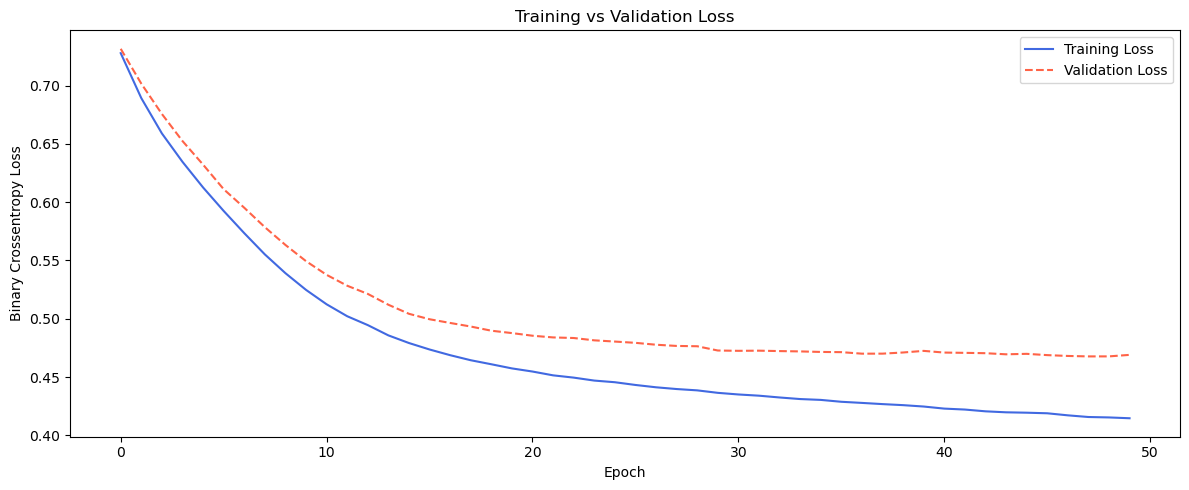

In [30]:
#Task 2.2
plt.figure(figsize=(12,5))


plt.plot(hasil_model.history['loss'], label='Training Loss', color='royalblue', )
plt.plot(hasil_model.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.tight_layout()


plt.show()

In [10]:
#Task 2.3
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7597 - loss: 0.5764 
Test Loss: 0.5764
Test Accuracy: 0.7597


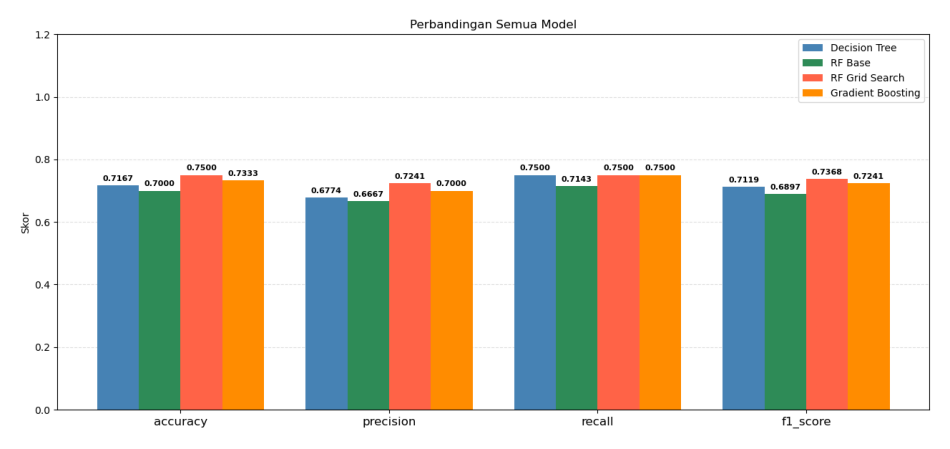

In [11]:
img = mpimage.imread('hasil_ML_assignment_sesi_19.png')

plt.figure(figsize=(12, 8)) 
plt.imshow(img)
plt.axis('off')
plt.show()

**#Task 2.4**\
Walaupun dataset berbeda ini merupakan perbandingan hasil akurasi antar model.
| Model | Akurasi |
|-------|---------|
| Decision Tree | 0.7267 |
| Random Forest Base | 0.7000 |
| Random Forest Grid Search | 0.7500 |
| Gradient Boosting | 0.7333 |
| Keras Sequential Model | 0.7597 |

In [29]:
print(f'Final training loss: {hasil_model.history['loss'][-1]}')
print(f'Final validation loss: {hasil_model.history['val_loss'][-1]}')
print(f'Selisih: {hasil_model.history['val_loss'][-1] - hasil_model.history['loss'][-1]}')

Final training loss: 0.4146166145801544
Final validation loss: 0.4689921438694
Selisih: 0.054375529289245605


**Task 2.5**\
Terdapat indikasi bahwa model sudah mulai overfitting karena training loss dan validation loss stagnan pada setelah epoch ke 30 ke atas. Tetapi tidak terlalu parah karena selisih antara kedua loss tersebut sekitar 0.05 dan tidak melebihinya. Secara visual validation loss juga tidak menambah besar sehingga masih dalam posisi model dapat generalisasi.